# 04. 돌발상황 위험도 스코어링

각 돌발 레코드에 **위치 / 돌발유형 / 차로통제 / 시간대** 4개 항목의 점수를 매겨
0~100점 척도의 위험도 점수(`risk_score`)를 산출한다. 배점 구조는 원본 보고서
2.1.2절 로직을 참고했다.

| 항목 | 배점 | 기준 |
|---|---|---|
| 위치 점수 | 0~20 | 터널 20 / 교량(~대교,~육교,~N교,교량) 15 / IC·JC·JCT·분기 10 / 고속도로 8 / 일반도로 3 / 없음 0 |
| 돌발 점수 | 0~25 | 사고 25 / 고장 15 / 공사·작업·시설점검 10 / 정체·지체 5 / 기상 3 / 기타 0 |
| 차로 점수 | 0~40 | 전면통제·전체차로 40 / 2개 이상 차로차단 30 / 1개 차로차단 20 / 갓길 10 / 정보없음 0 |
| 시간 점수 | 0~15 | 출퇴근(7-9, 17-19시) 15 / 주간(10-16시) 10 / 야간·심야 5 |

**주의**: `돌발내용`은 자유 텍스트라 정규식/키워드 기반으로 항목을 판별한다.
아래 각 절에서 실제 매칭 사례를 함께 확인하며 규칙을 검증했다 (예: "차로교대",
"판교", "OO교회" 등은 교량이 아니므로 위치 점수에서 제외되도록 보정).

In [1]:
import sys, pathlib, re
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.load_data import load
from src.plot_config import set_korean_style

set_korean_style()
FIG_DIR = pathlib.Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load()
df.shape

(623188, 19)

## 4.1 위치 점수 (0~20)

In [2]:
TUNNEL_RE = re.compile(r'터널')
# '대교/육교/교량'은 무조건 교량, 'N교'(고잔3교, 무안1교 등 숫자+교)도 교량 명명 패턴으로 인정.
# 단순 'X교' 패턴은 '판교'(지명), 'OO교회', '차로교대'처럼 교량이 아닌 오탐이 많아 제외했다.
BRIDGE_RE = re.compile(r'대교|육교|교량|\d교(?:$|[^통])')
IC_JC_RE = re.compile(r'IC|JC|JCT|분기')
HIGHWAY_TYPES = {'고속국도', '도시고속도로'}
NORMAL_ROAD_TYPES = {'일반국도', '지방도', '국가지원지방도', '시군도', '특별광역시도'}


def location_score(row):
    text = row['돌발내용'] if pd.notna(row['돌발내용']) else ''
    if TUNNEL_RE.search(text):
        return 20
    if BRIDGE_RE.search(text):
        return 15
    if IC_JC_RE.search(text):
        return 10
    road_type = row['도로타입']
    if road_type in HIGHWAY_TYPES:
        return 8
    if road_type in NORMAL_ROAD_TYPES:
        return 3
    return 0


df['loc_score'] = df.apply(location_score, axis=1)
df['loc_score'].value_counts().sort_index(ascending=False)

loc_score
20     29585
15     37810
10     70123
8     381943
3      99425
0       4302
Name: count, dtype: int64

## 4.2 돌발 점수 (0~25)

In [3]:
ACCIDENT_DETAILS = {'사고', '추돌사고', '단독사고', '화재사고', '전도사고', '충돌사고', '역주행', '시설물사고'}
BREAKDOWN_DETAILS = {'고장', '고장차'}
WORK_DETAILS = {'작업', '시설물보수작업', '노면보수작업', '도로포장', '차선도색', '가로등작업', '이동작업', '교량점검'}
CONGESTION_DETAILS = {'차량증가/정체', '지정체'}
WEATHER_DETAILS = {'강우', '적설', '안개', '강풍', '노면습기', '결빙', '강설', '호우', '대설', '노면결빙', '침수', '하천범람', '도로유실', '낙석', '산사태'}


def incident_score(row):
    detail, category = row['돌발상세구분'], row['돌발구분']
    if detail in ACCIDENT_DETAILS or category == '교통사고':
        return 25
    if detail in BREAKDOWN_DETAILS:
        return 15
    if detail in WORK_DETAILS or category == '공사':
        return 10
    if detail in CONGESTION_DETAILS:
        return 5
    if detail in WEATHER_DETAILS or category == '기상':
        return 3
    return 0  # 통제/보행자/이벤트/이륜차/화재/장애물 등 미분류 -> 기타


df['inc_score'] = df.apply(incident_score, axis=1)
df['inc_score'].value_counts().sort_index(ascending=False)

inc_score
25    146546
15     86532
10    201338
5     105803
3      50345
0      32624
Name: count, dtype: int64

## 4.3 차로 점수 (0~40)

In [4]:
LANE_NUM_RE = re.compile(r'(\d(?:,\d)+|\d)차로')


def lane_score(text):
    if pd.isna(text):
        return 0
    text = str(text)
    if '전면통제' in text or '전체차로' in text:
        return 40
    nums = set()
    for m in LANE_NUM_RE.finditer(text):
        nums.update(m.group(1).split(','))
    if len(nums) >= 2:
        return 30
    if len(nums) == 1:
        return 20
    if '차로교대' in text:
        return 20
    if '갓길' in text:
        return 10
    return 0


df['lane_score'] = df['돌발내용'].apply(lane_score)
df['lane_score'].value_counts().sort_index(ascending=False)

lane_score
40      2033
30     30389
20    251504
10    115422
0     223840
Name: count, dtype: int64

## 4.4 시간 점수 (0~15)

In [5]:
def time_score(hour):
    if hour in (7, 8, 9, 17, 18, 19):
        return 15
    if 10 <= hour <= 16:
        return 10
    return 5  # 야간/심야 (20~23시, 0~6시)


df['time_score'] = df['hour'].apply(time_score)
df['time_score'].value_counts().sort_index(ascending=False)

time_score
15    232790
10    280191
5     110207
Name: count, dtype: int64

## 4.5 최종 위험도 점수

In [6]:
df['risk_score'] = df['loc_score'] + df['inc_score'] + df['lane_score'] + df['time_score']
df['risk_score'].describe()

count    623188.000000
mean         43.150773
std          15.894317
min           8.000000
25%          28.000000
50%          43.000000
75%          53.000000
max         100.000000
Name: risk_score, dtype: float64

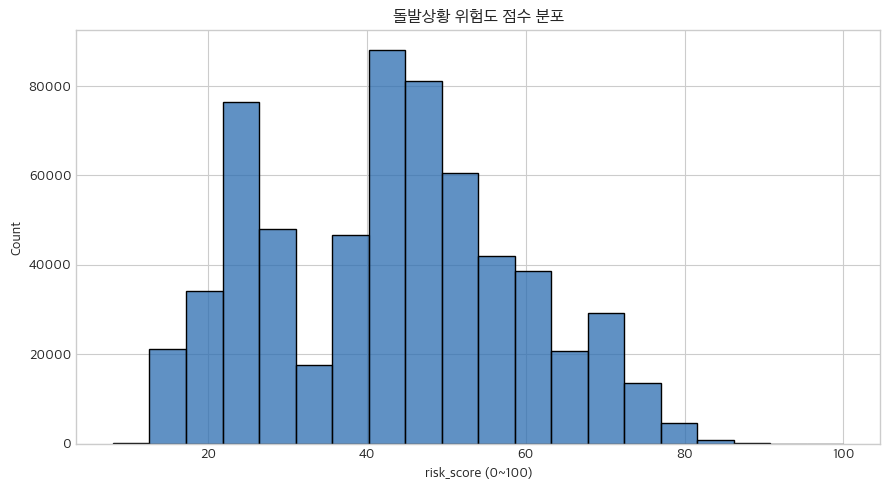

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['risk_score'], bins=20, ax=ax, color='#2b6cb0')
ax.set_title('돌발상황 위험도 점수 분포')
ax.set_xlabel('risk_score (0~100)')
plt.tight_layout()
plt.savefig(FIG_DIR / '11_risk_score_distribution.png', dpi=150)
plt.show()

## 4.6 카테고리(돌발상세구분)별 평균 위험도

,빈도,평균위험도
돌발상세구분,,
사고,144066,60.994780
역주행,319,55.169279
화재사고,39,50.692308
작업,191487,47.058991
고장,86529,45.199667
단독사고,44,43.840909
장애물,19950,40.742356
추돌사고,2005,40.158105
행사,3584,40.025670


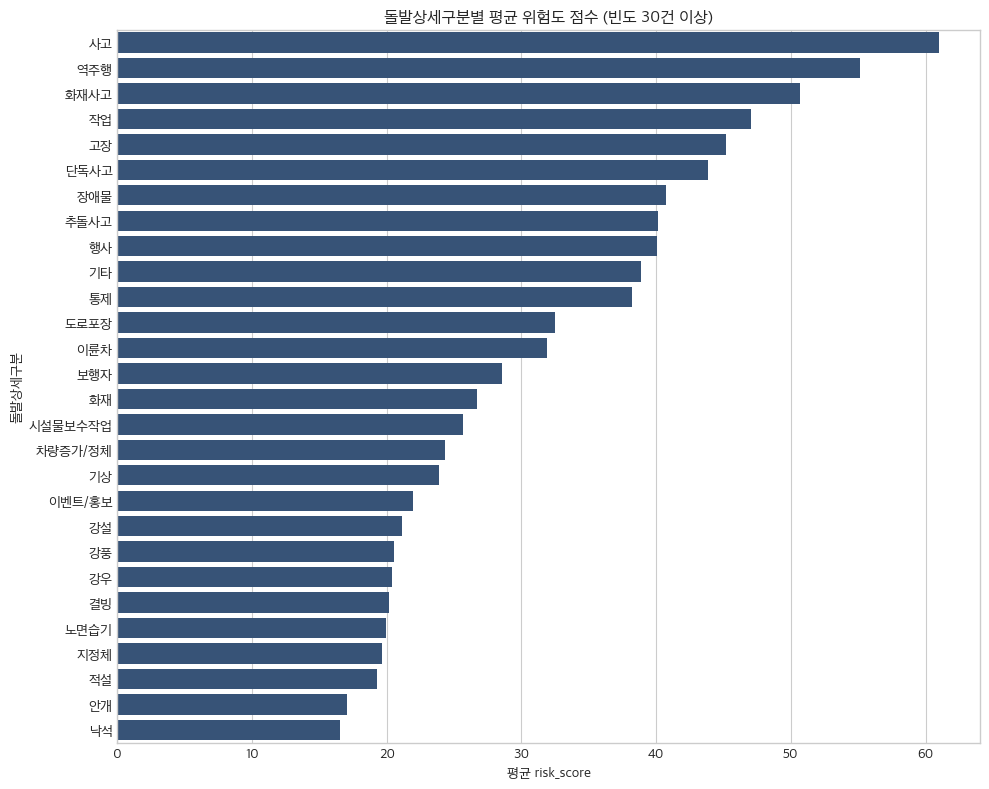

In [8]:
category_stats = (
    df.groupby('돌발상세구분')['risk_score']
    .agg(빈도='count', 평균위험도='mean')
    .query('빈도 >= 30')
    .sort_values('평균위험도', ascending=False)
)
display(category_stats)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=category_stats['평균위험도'], y=category_stats.index, ax=ax, color='#2c5282')
ax.set_title('돌발상세구분별 평균 위험도 점수 (빈도 30건 이상)')
ax.set_xlabel('평균 risk_score')
ax.set_ylabel('돌발상세구분')
plt.tight_layout()
plt.savefig(FIG_DIR / '12_avg_risk_score_by_category.png', dpi=150)
plt.show()

## 4.7 위험기여도 Top5 (빈도 × 평균영향도)\n\n발생 빈도가 낮아도 평균 위험도가 높은 유형(예: 터널·교량 사고)과, 빈도는 높지만 영향도가 낮은 유형(예: 정체)을 구분하기 위해 `빈도 × 평균위험도`로 위험기여도를 계산한다.

,빈도,평균위험도,위험기여도
돌발상세구분,,,
작업,191487,47.058991,9011185.0
사고,144066,60.994780,8787274.0
고장,86529,45.199667,3911082.0
차량증가/정체,103248,24.308984,2509854.0
장애물,19950,40.742356,812810.0


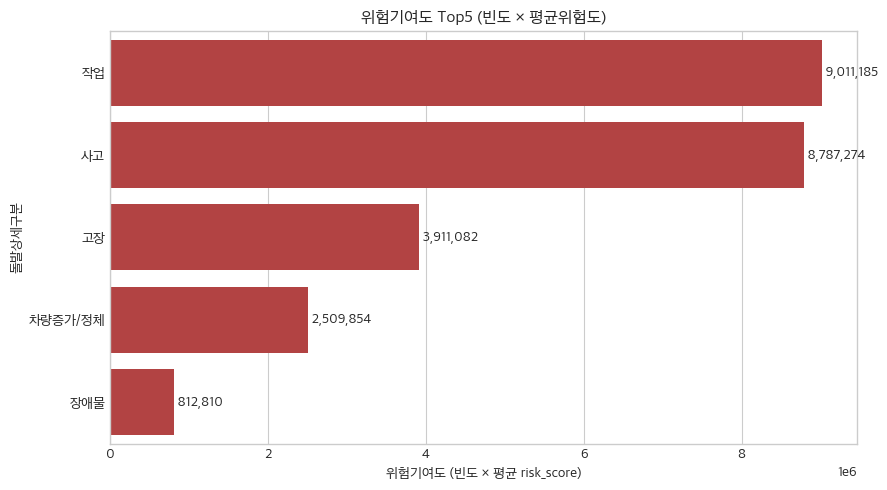

In [9]:
category_stats['위험기여도'] = category_stats['빈도'] * category_stats['평균위험도']
top5 = category_stats.sort_values('위험기여도', ascending=False).head(5)
display(top5)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top5['위험기여도'], y=top5.index, ax=ax, color='#c53030')
ax.set_title('위험기여도 Top5 (빈도 × 평균위험도)')
ax.set_xlabel('위험기여도 (빈도 × 평균 risk_score)')
ax.set_ylabel('돌발상세구분')
for i, v in enumerate(top5['위험기여도']):
    ax.text(v, i, f' {v:,.0f}', va='center')
plt.tight_layout()
plt.savefig(FIG_DIR / '13_risk_contribution_top5.png', dpi=150)
plt.show()